# 🌎 Economic Complexity Analysis: Latin America & Caribbean

This notebook analyzes the **Economic Complexity Index (ECI)** for countries in Latin America and the Caribbean across four dimensions:
- **Production (P)**: Based on exports and manufacturing output.
- **Technology (T)**: Based on patent data.
- **Science (S)**: Based on scientific publications.
- **Entrepreneurial (E)**: Based on venture capital and startup activity.

We investigate the current rankings as of 2023 and the evolution of complexity over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ecomplexity import ecomplexity
import warnings
warnings.filterwarnings('ignore')

# Set premium aesthetic settings
plt.rcParams.update({
    'figure.dpi': 120, 
    'font.family': 'sans-serif', 
    'font.size': 10, 
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold',
    'grid.alpha': 0.3,
    'figure.facecolor': 'white'
})
sns.set_style("whitegrid")

DIM_COLORS = {'Production': '#00B0F0', 'Technology': '#2E75B6', 'Science': '#A9D18E', 'Entrepreneurial': '#C5E0B4'}
DIM_LABELS = {'P': 'Production', 'T': 'Technology', 'S': 'Science', 'E': 'Entrepreneurial'}

print('✅ Libraries and settings loaded')

✅ Libraries and settings loaded


## 1. Load Data
We load the output data and filter for countries in the **Latin America and the Caribbean** region.

In [2]:
# Load mapping files
units = pd.read_parquet('data/units.parquet')
fields = pd.read_parquet('data/fields.parquet')

# Identify LATAM countries
latam_units = units[units['Continent'] == 'Latin America and the Caribbean']['Unit'].unique()
latam_names = units[units['Continent'] == 'Latin America and the Caribbean'][['Unit', 'Unit Name']].drop_duplicates().set_index('Unit')['Unit Name'].to_dict()

# Load output data
outputs = pd.read_parquet('data/outputs.parquet')

# Map Dimension codes to names for readability later
outputs['Dimension Name'] = outputs['Dimension'].map(DIM_LABELS)

print(f"Found {len(latam_units)} countries in Latin America & Caribbean.")

Found 33 countries in Latin America & Caribbean.


## 2. Calculate ECI for all Dimensions
We compute the Economic Complexity Index for each dimension and year. This calculation is performed on the global dataset to ensure results are comparable to international benchmarks.

In [3]:
trade_cols = {'time': 'Period', 'loc': 'Unit', 'prod': 'Field ID', 'val': 'Outputs (Fractional)'}
results_list = []

for dim_code in ['P', 'T', 'S', 'E']:
    print(f"Processing Dimension: {DIM_LABELS[dim_code]}...")
    dim_data = outputs[outputs['Dimension'] == dim_code][[ 
        'Period', 'Unit', 'Field ID', 'Outputs (Fractional)'
    ]].copy()
    
    # Calculate ECI globally
    res = ecomplexity(dim_data, trade_cols)
    res['Dimension'] = dim_code
    results_list.append(res)

all_eci = pd.concat(results_list, ignore_index=True)

# Filter to LATAM and aggregate
latam_eci = all_eci[all_eci['Unit'].isin(latam_units)].copy()
latam_eci['Country'] = latam_eci['Unit'].map(latam_names)
latam_eci_summary = latam_eci.drop_duplicates(['Period', 'Unit', 'Dimension'])[['Period', 'Unit', 'Country', 'Dimension', 'eci']]

print("✅ ECI calculation complete.")

Processing Dimension: Production...
2001
Percentage of pairs compared that meet log-supermodularity condition: 29.70%
2002
Percentage of pairs compared that meet log-supermodularity condition: 13.45%
2003
Percentage of pairs compared that meet log-supermodularity condition: 38.70%
2004
Percentage of pairs compared that meet log-supermodularity condition: 24.67%
2005
Percentage of pairs compared that meet log-supermodularity condition: 34.91%
2006
Percentage of pairs compared that meet log-supermodularity condition: 46.36%
2007
Percentage of pairs compared that meet log-supermodularity condition: 30.31%
2008
Percentage of pairs compared that meet log-supermodularity condition: 29.01%
2009
Percentage of pairs compared that meet log-supermodularity condition: 38.83%
2010
Percentage of pairs compared that meet log-supermodularity condition: 26.72%
2011
Percentage of pairs compared that meet log-supermodularity condition: 40.08%
2012
Percentage of pairs compared that meet log-supermodularit

## 3. Comparison by Dimension (2023)
The heatmap below shows the current complexity landscape. Higher scores (blue) indicate more complex capabilities.

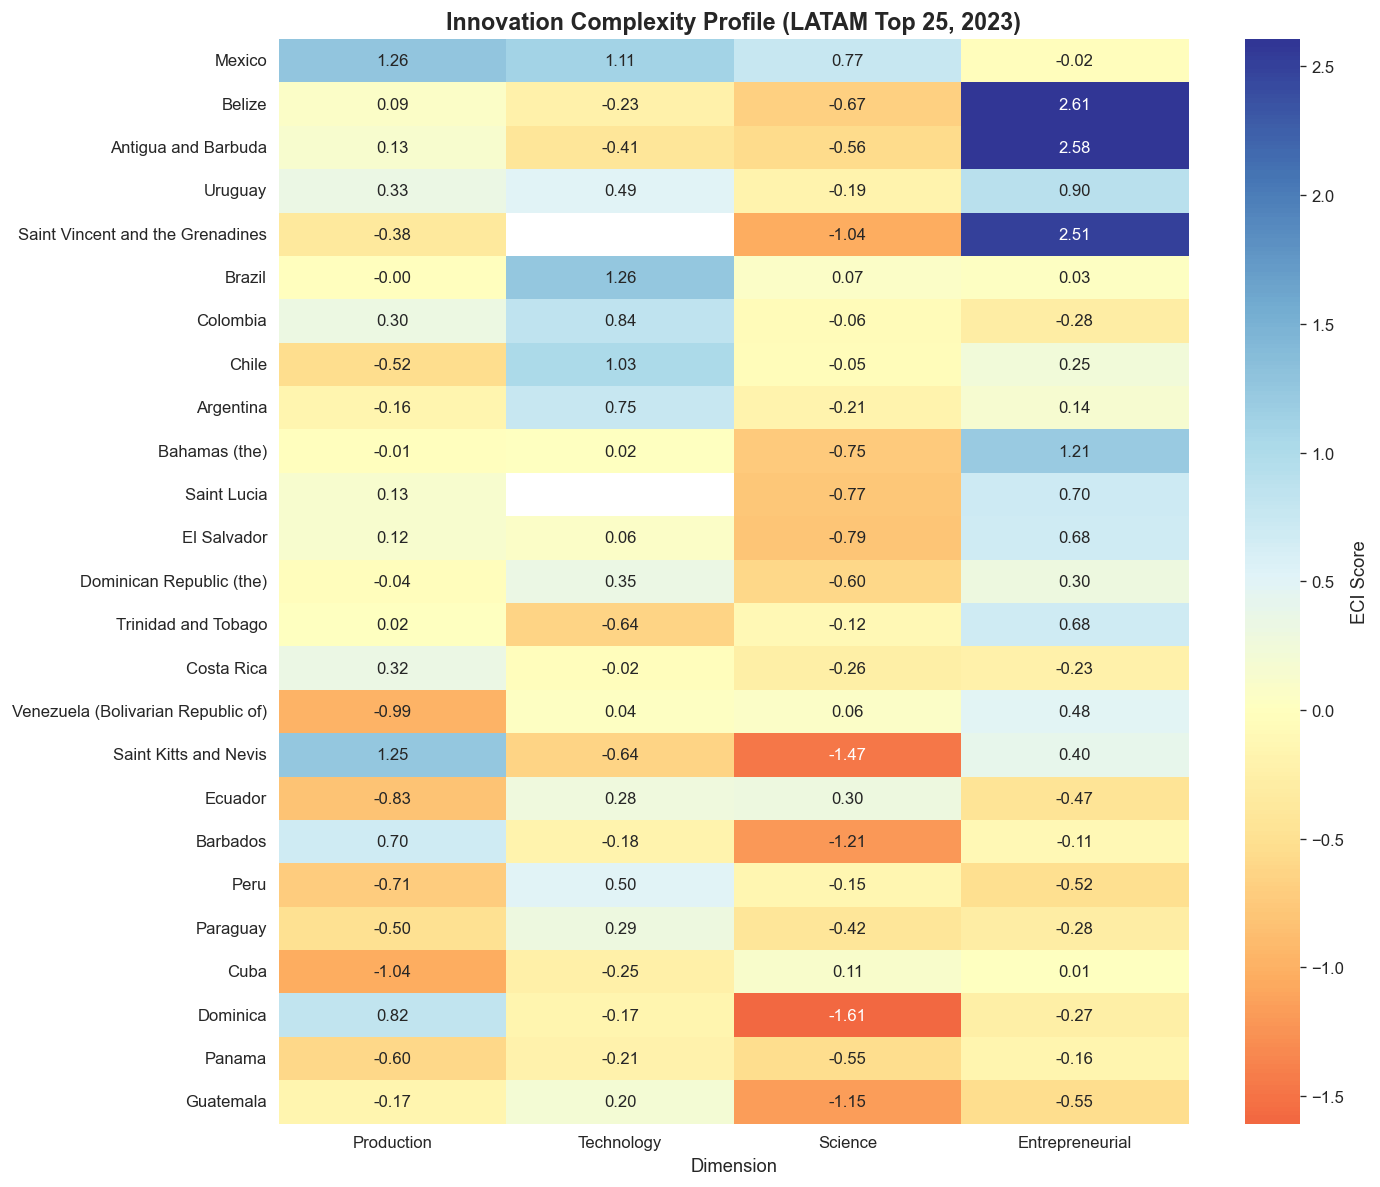

In [4]:
# Pivot for 2023 comparison
eci_2023 = latam_eci_summary[latam_eci_summary['Period'] == 2023].pivot(
    index='Country', columns='Dimension', values='eci'
).rename(columns=DIM_LABELS)

# Calculate Average ECI
eci_2023['Average'] = eci_2023.mean(axis=1)
eci_2023 = eci_2023.sort_values('Average', ascending=False)

# Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(eci_2023[[d for d in DIM_LABELS.values()]].head(25), 
            annot=True, fmt=".2f", cmap="RdYlBu", center=0, 
            cbar_kws={'label': 'ECI Score'})
plt.title("Innovation Complexity Profile (LATAM Top 25, 2023)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 4. Ranking (2023)
Ranking based on the average performance across all four pillars of innovation.

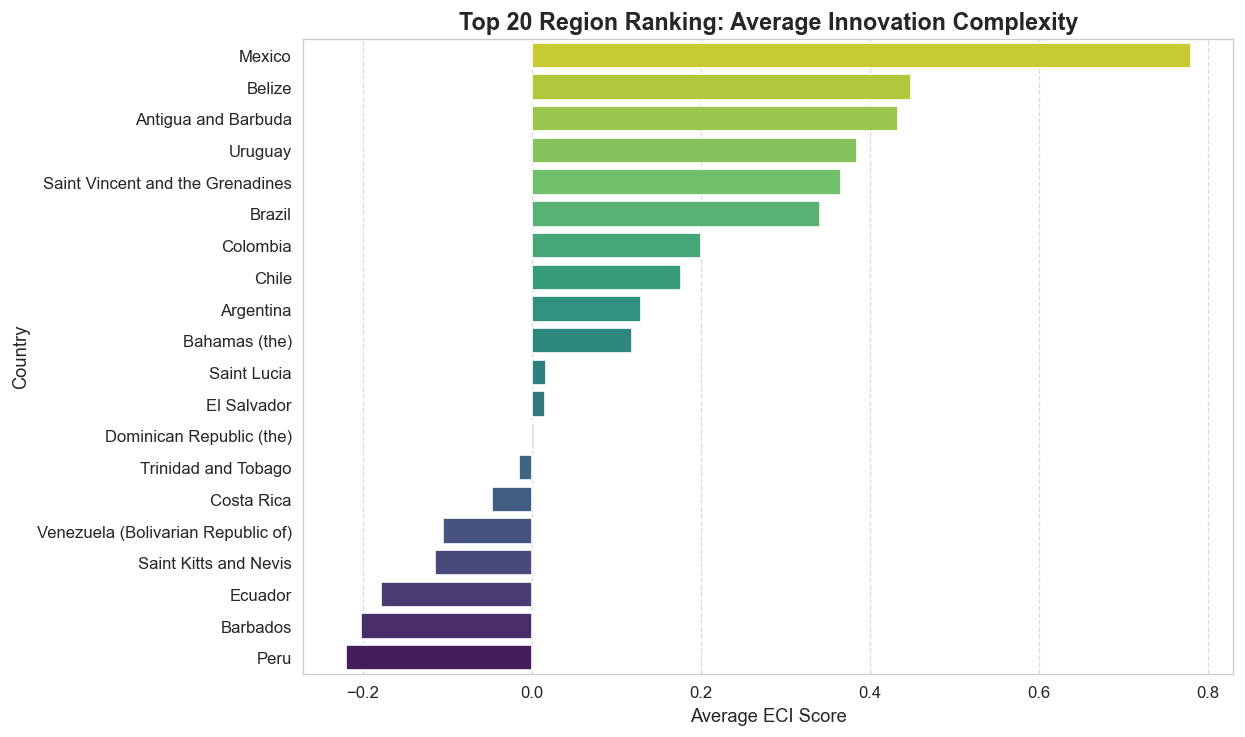

In [5]:
top_latam = eci_2023.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("viridis_r", len(top_latam))
sns.barplot(data=top_latam.reset_index(), x='Average', y='Country', palette=palette)
plt.title("Top 20 Region Ranking: Average Innovation Complexity")
plt.xlabel("Average ECI Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 5. Evolution of Complexity
Tracking the long-term trends of the region's largest economies.

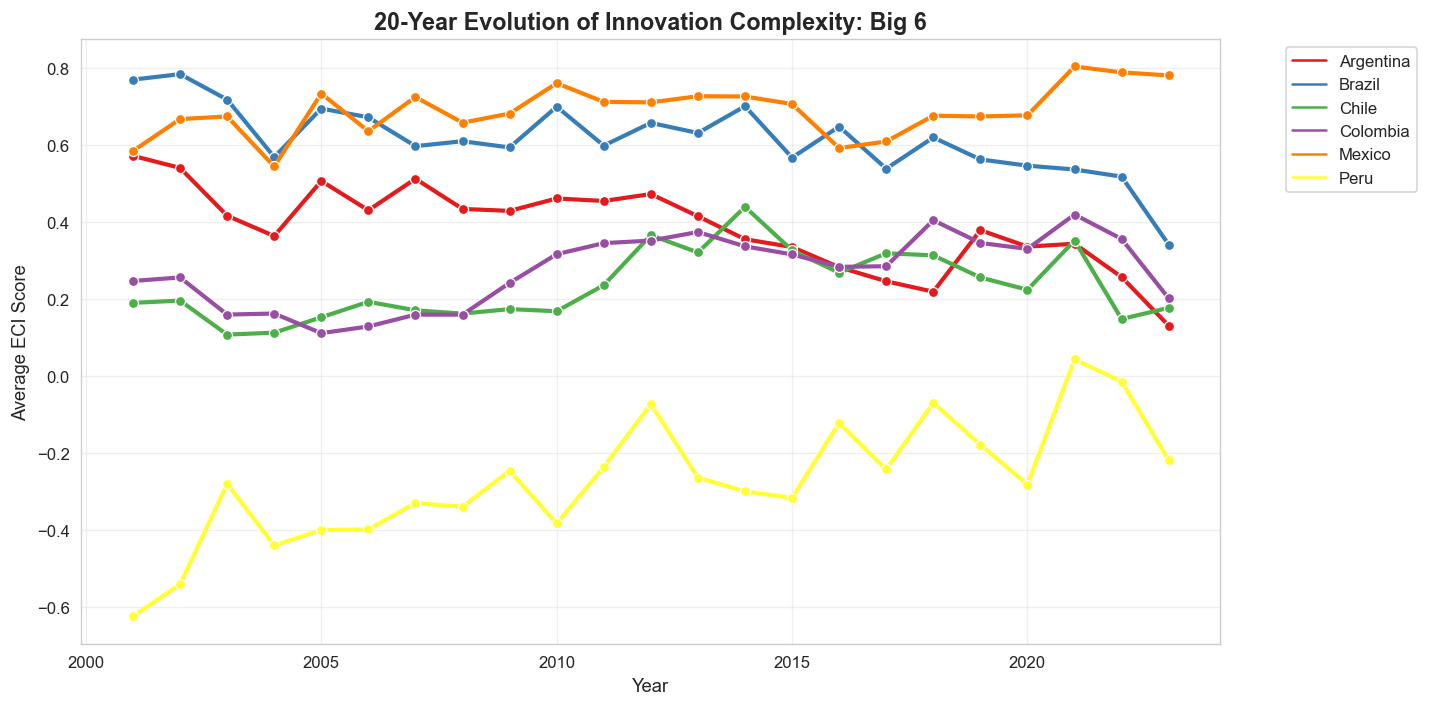

In [6]:
big_6 = ['Brazil', 'Mexico', 'Argentina', 'Chile', 'Colombia', 'Peru']
evolution_data = latam_eci_summary[latam_eci_summary['Country'].isin(big_6)]

avg_evolution = evolution_data.groupby(['Period', 'Country'])['eci'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_evolution, x='Period', y='eci', hue='Country', marker='o', linewidth=2.5, palette='Set1')
plt.title("20-Year Evolution of Innovation Complexity: Big 6")
plt.ylabel("Average ECI Score")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Highest Complexity Growth
Comparing the change in complexity between the start and end of the observations.

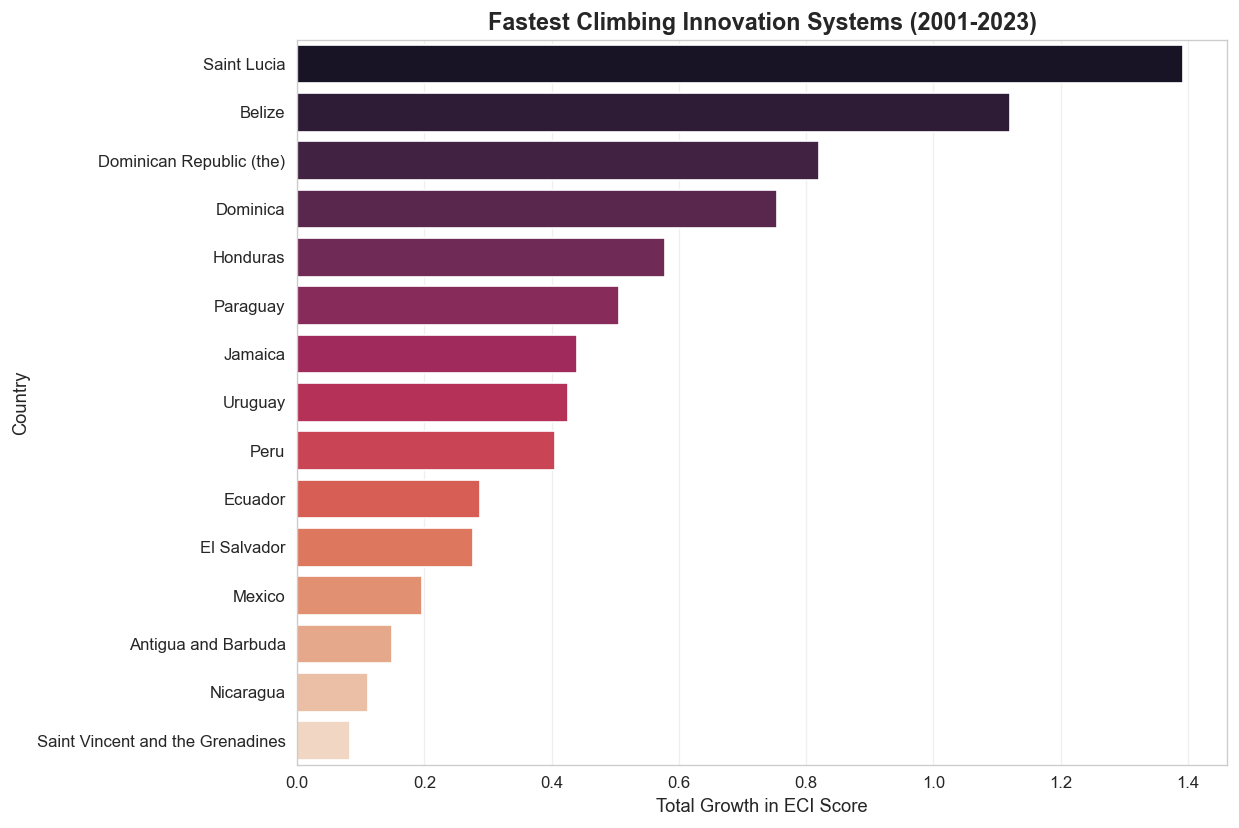

In [7]:
avg_all = latam_eci_summary.groupby(['Period', 'Country'])['eci'].mean().reset_index()
first_year = avg_all['Period'].min()
last_year = avg_all['Period'].max()

growth = avg_all[avg_all['Period'].isin([first_year, last_year])].pivot(index='Country', columns='Period', values='eci')
growth['Delta'] = growth[last_year] - growth[first_year]
growth = growth.sort_values('Delta', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=growth.head(15).reset_index(), x='Delta', y='Country', palette='rocket')
plt.title(f"Fastest Climbing Innovation Systems ({first_year}-{last_year})")
plt.xlabel("Total Growth in ECI Score")
plt.show()

### Dimension Analysis for Case Study

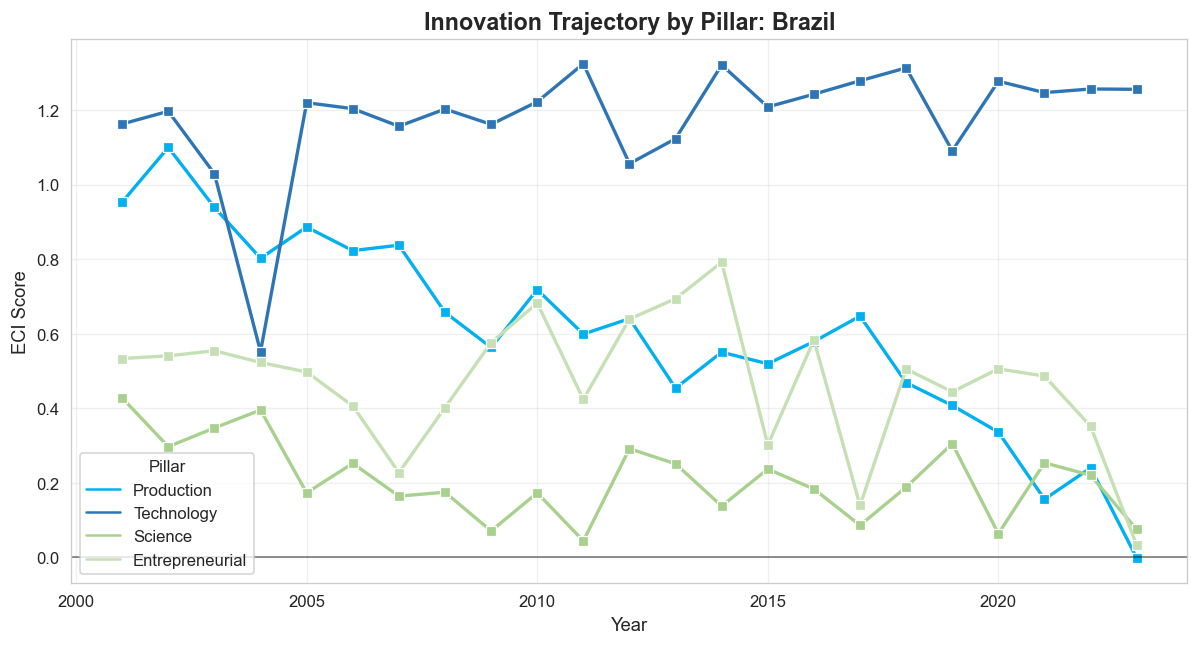

In [10]:
country_choice = 'Brazil'
country_evol = latam_eci_summary[latam_eci_summary['Country'] == country_choice].copy()
country_evol['Dimension Name'] = country_evol['Dimension'].map(DIM_LABELS)

plt.figure(figsize=(12, 6))
sns.lineplot(data=country_evol, x='Period', y='eci', hue='Dimension Name', 
             palette=DIM_COLORS, marker='s', linewidth=2)
plt.title(f"Innovation Trajectory by Pillar: {country_choice}")
plt.ylabel("ECI Score")
plt.xlabel("Year")
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.legend(title="Pillar")
plt.show()